# Bilateral Symmetry Analysis
Welcome to the final tutorial! In the previous notebook, we used `Synchronization` to see if the left and right hands were moving at the same time (Temporal Phase).

In this notebook, we look at **Geometric Symmetry**: Are the left and right limbs physically mirroring each other in 3D space?

This is a critical metric in clinical rehabilitation (e.g., assessing gait symmetry after a stroke) and sports biomechanics. We will evaluate the spatial mirroring of the hands and the feet relative to the body's center.

## Loading the Data & Identifying Joints
To calculate bilateral symmetry, we need to explicitly tell the algorithm which joints represent the "Left" side, which represent the "Right" side, and which joint represents the "Center of Symmetry" (usually the Pelvis or Neck).

In [5]:
from utils.data_loader import load_qualisys_tsv
from utils.plot_utils import plot_feature_timeseries

# Load spatial data
pos_tensor, _, _, marker_names = load_qualisys_tsv("data/trial0001_impulsive.tsv")

# Identify the indices for our left/right pairs and our center
l_hand_idx = marker_names.index("HAND_LEFT")
r_hand_idx = marker_names.index("HAND_RIGHT")

l_foot_idx = marker_names.index("FOOT_LEFT")
r_foot_idx = marker_names.index("FOOT_RIGHT")

center_idx = marker_names.index("SPINE_BASE")

print(f"Tracking Symmetry for Hands ({l_hand_idx}, {r_hand_idx}) and Feet ({l_foot_idx}, {r_foot_idx})")
print(f"Center of Symmetry: PELVIS ({center_idx})")

Tracking Symmetry for Hands (22, 21) and Feet (15, 13)
Center of Symmetry: PELVIS (19)


## Setting up the Symmetry Feature
How does the algorithm actually calculate symmetry?
For every frame, it shifts the 3D coordinate system so the `center_idx` is at `(0,0,0)`. It then takes the Right joint, mathematically reflects it across the sagittal plane (the X-axis), and measures the Euclidean distance to the Left joint.

$$Error = || Left - Reflected(Right) ||$$

Because frame-by-frame spatial data can be jittery, `GeometricSymmetry` is implemented as a **Dynamic Feature**. It averages this spatial error over a sliding window to give you a smooth, robust evaluation of the subject's posture.

In [6]:
from pyeyesweb.data_models.sliding_window import SlidingWindow
from pyeyesweb.low_level.geometric_symmetry import GeometricSymmetry

# 1. Initialize Window
# We use a 30-frame (~0.3 seconds) window to smooth out micro-jitters
sw_pos = SlidingWindow(max_length=30, n_signals=pos_tensor.shape[1], n_dims=3)

# 2. Initialize Feature
# We pass a list of tuples defining our pairs
joint_pairs = [
    (l_hand_idx, r_hand_idx),
    (l_foot_idx, r_foot_idx)
]

symmetry_feature = GeometricSymmetry(
    joint_pairs=joint_pairs,
    center_of_symmetry=center_idx
)

## The Execution Loop
When we call `to_flat_dict("sym")` on the `GeometricSymmetryResult`, the library automatically unrolls our pairs list into easy-to-read dictionary keys, formatted as `sym_pair_{left_idx}_{right_idx}`.

Evaluating Symmetry: 100%|██████████| 7289/7289 [00:00<00:00, 18685.74it/s]


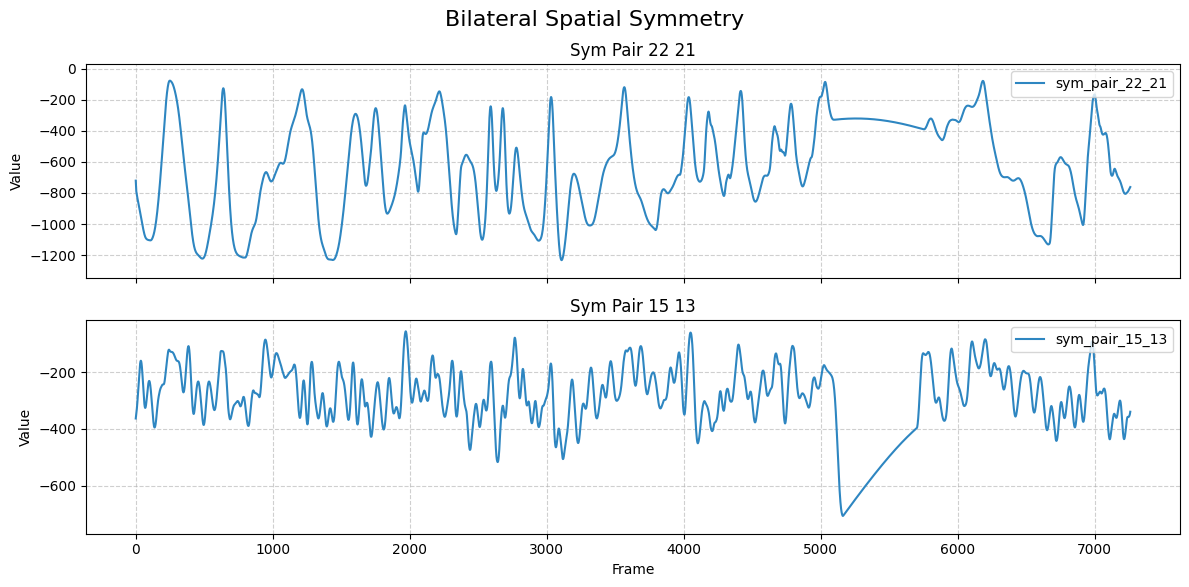

In [8]:
from tqdm.auto import tqdm

results = []

for pos_frame in tqdm(pos_tensor, desc="Evaluating Symmetry"):

    # 1. Push to window
    sw_pos.append(pos_frame)

    # 2. Wait for the window to fill
    if len(sw_pos) < sw_pos.max_length:
        continue

    # 3. Compute and flatten
    res_sym = symmetry_feature(sw_pos).to_flat_dict("sym")
    results.append(res_sym)


# 4. Dynamically generate the metric names we want to plot based on our indices
hand_metric = f"sym_pair_{l_hand_idx}_{r_hand_idx}"
foot_metric = f"sym_pair_{l_foot_idx}_{r_foot_idx}"

plot_feature_timeseries(
    results_list=results,
    metrics_to_plot=[hand_metric, foot_metric],
    title="Bilateral Spatial Symmetry"
)

**Interpreting the Plot**

- **Values near 1.0**: The left and right limbs are perfectly mirrored across the body's center. For example, the subject is standing with feet shoulder-width apart and both arms resting equally at their sides.

**Drops in the value**: The symmetry is broken. The subject might have raised their right arm while leaving their left arm down, or stepped forward with only their left foot.

By tracking these values over time, you can easily classify whether a subject is performing symmetrical actions (like jumping jacks or rowing) or asymmetrical actions (like throwing a baseball or walking)!